# cellAdmix with a Seurat Xenium Object

In [ ]:
knitr::opts_chunk$set(echo = TRUE, message = TRUE, warning = TRUE,
  fig.width = 8, fig.height = 6, dpi = 120)

library(Seurat)
library(cellAdmixCore)
library(ggplot2)
library(cowplot)

## Overview

This example shows how to use cellAdmix when the cell-level analysis is
managed in Seurat. Seurat defines the active cells, active genes, cell
annotations, and downstream object that users keep working with.
cellAdmix uses the original Xenium bundle as a molecule-complete backing
source, fits molecular admixture factors, scores likely source/target
relationships, removes putative admixture molecules, and writes
corrected counts back into the Seurat object as a new assay.

The core workflow is:

In [ ]:
seu <- LoadXenium("data", molecule.coordinates = FALSE)
seu$cell_type <- ...

ds <- cellAdmix(seu, xenium_dir = "data", output_dir = "out",
  annotation = "cell_type")
fit <- ds$fit()
score <- fit$score_membrane()
correction <- score$correct()

seu <- celladmix_add_to_seurat(seu, fit = fit, score = score,
  correction = correction, corrected_assay = "cellAdmix")

We use `molecule.coordinates = FALSE` when loading Seurat because
cellAdmix reads the complete transcript table directly from the Xenium
bundle. This avoids duplicating all molecules in R memory and preserves
Xenium fields that Seurat’s molecule object does not keep.

## Input Data

This example uses the 10x Genomics [FFPE human pancreas Xenium
dataset](https://www.10xgenomics.com/datasets/ffpe-human-pancreas-with-xenium-multimodal-cell-segmentation-1-standard).
Download and unpack the bundle into a folder named `data` next to this
notebook:

In [ ]:
curl -O https://cf.10xgenomics.com/samples/xenium/2.0.0/Xenium_V1_human_Pancreas_FFPE/Xenium_V1_human_Pancreas_FFPE_outs.zip
unzip Xenium_V1_human_Pancreas_FFPE_outs.zip
mv outs data

The quick cell-type annotations used here are for demonstration only.
They were derived from a lightweight clustering/marker workflow in the
companion pancreas annotation notebook and are intentionally not treated
as a curated reference. In a normal Seurat analysis, these labels would
usually come from standard Seurat clustering, marker inspection,
reference mapping, or another annotation workflow. Here we load
predetermined labels only to keep the example focused on cellAdmix
integration. Place `annotation.csv.gz` in an `annotations` folder next
to this notebook.

In [ ]:
data_dir <- "data"
annotation_file <- file.path("annotations", "annotation.csv.gz")

stopifnot(dir.exists(data_dir))
stopifnot(file.exists(annotation_file))

## Load Xenium into Seurat

We first create a normal Seurat object from the Xenium output. This is
where a typical Seurat workflow would do QC, subsetting, normalization,
clustering, and manual or automated annotation. In this tutorial, we
keep that part minimal and attach the precomputed example annotations.

The annotation file is a gzip-compressed CSV with one row per cell. We
use `cell_id` to match rows to Seurat cells, and `merged_annotation` as
the cell-type label that will be stored in `seu$cell_type`.

In [ ]:
seu <- LoadXenium(data_dir, fov = "fov", assay = "Xenium",
  molecule.coordinates = FALSE)

Cell_seg columns: cell_id, x_centroid, y_centroid, transcript_counts, control_probe_counts, control_codeword_counts, unassigned_codeword_counts, deprecated_codeword_counts, total_counts, cell_area, nucleus_area

Adding default segmentation_method = 'cell'

10X data contains more than one type and is being returned as a list containing matrices of each type.

('-')
('-')
('-')
('-')
('-')
('-')

Not validating FOV objects
Not validating FOV objects


Ductal/tumor epithelial               Endocrine             Endothelial 
                  29986                    2212                    7026 
    Exocrine epithelial        Fibroblast / CAF                  Immune 
                  36329                   28366                   19251 
       Mural / pericyte 
                   2553 

The Seurat object now defines the active analysis universe. If the
object had already been subsetted to particular cells or genes, the
cellAdmix adapter would pass those active cell and feature IDs as
filters to the Xenium-backed store.

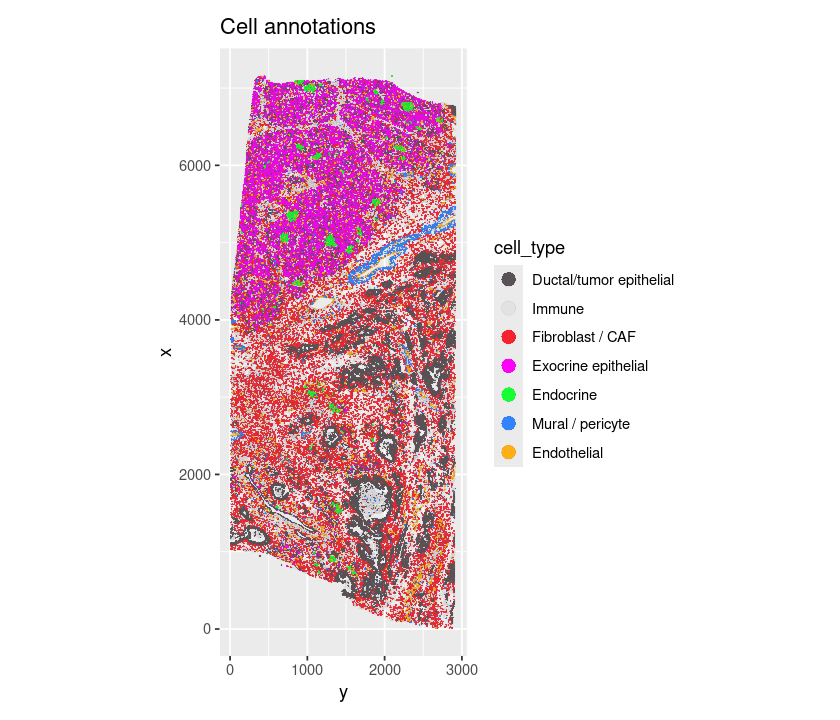

In [ ]:
ImageDimPlot(seu, fov = "fov", group.by = "cell_type",
  axes = TRUE, cols = "polychrome", dark.background = FALSE,
  border.color = "grey30", border.size = 0.03, alpha = 0.9) +
  ggtitle("Cell annotations")

## Construct cellAdmix Dataset

The constructor below is the main integration point. The first argument
is the Seurat object, while `xenium_dir` points to the original Xenium
bundle. The annotation argument names a Seurat metadata field. We do not
need to specify `assay` or `image` here because the defaults are
inferred from the Seurat object. The output directory stores the
cellAdmix project cache: encoded molecules, factorization output,
scores, correction results, and any reusable intermediate files.

cellAdmix can work with Seurat without loading molecule coordinates into
R memory, but it still needs a molecule-complete backing source for the
core fit/score/correct workflow. For Xenium data, that source is the
original bundle passed as `xenium_dir`; without it, the analysis is
limited to Seurat-side metadata/visualization or adding previously
computed cellAdmix results back to the object.

In [ ]:
output_dir <- "out_seurat"
num_threads <- min(10, parallel::detectCores())

ds <- cellAdmix(seu, xenium_dir = data_dir, output_dir = output_dir,
  annotation = "cell_type", num_threads = num_threads)

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation:cell_type (125723 cells, 7 labels)

## Fit Molecular Factors

`fit()` samples neighborhood composition vectors from molecules inside
cells and fits NMF factors. The default rank is chosen from the number
of annotation classes. Multiple random/cluster-initialized NMF runs are
run in parallel by default, and the lowest-loss solution is retained.

In [ ]:
fit <- ds$fit(verbose = TRUE)

[INFO 16:08:07 +75.334s] Reused compatible Xenium input store (0.000s)
[INFO 16:08:07 +75.334s] Built Xenium input store: 6104194 molecules, 125723 cells (0.088s)
[INFO 16:08:07 +0.000s] Starting store-backed fit
[INFO 16:08:07 +0.394s] Resolved store training strata for 125723 cells (0.194s)

cellAdmix fit
  run: fit_cell_type_rank9_ls_nmf 
  annotation: cell_type 
  rank: 9 
  NMF: ls_nmf 
  molecule scoring: gene_loadings 
  cells: 125723 
  transcripts: 6104194 

Top factor-loading genes help interpret each factor. The stability plot
shows whether important factors were consistently recovered across NMF
restarts.

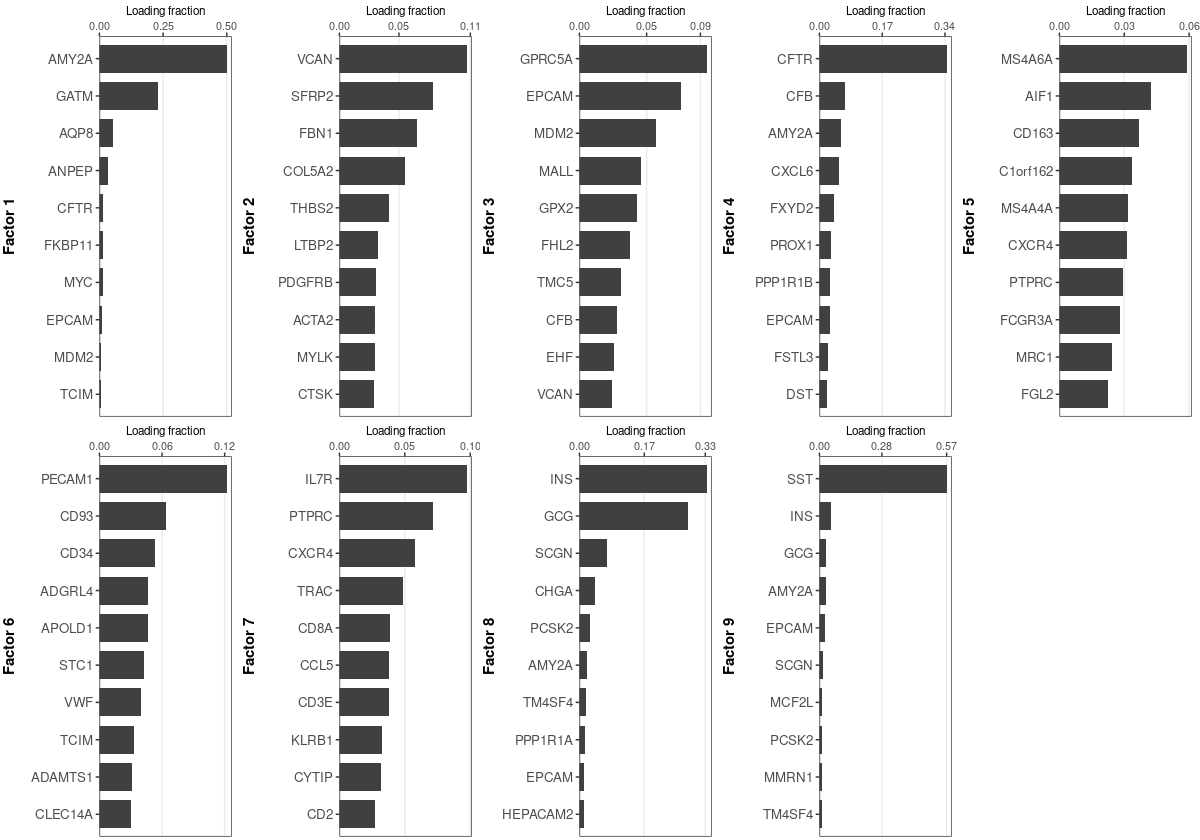

In [ ]:
fit$plot_loadings()

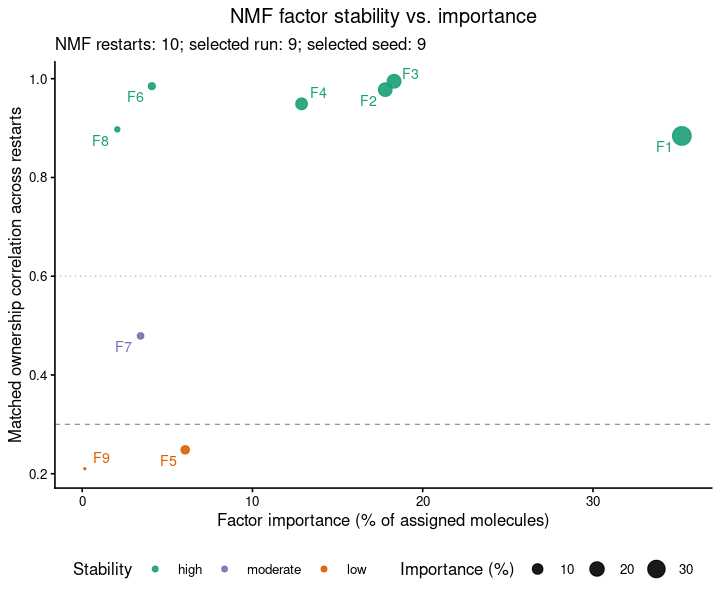

In [ ]:
fit$plot_stability()

## Membrane-Based Scoring

This Xenium run includes membrane staining, so we use membrane scoring.
The score summarizes which factor-cell-type combinations look more
consistent with external admixture than with native signal.

In [ ]:
membrane_score <- fit$score_membrane(verbose = TRUE)

[INFO 16:08:33 +1.114s] Loaded membrane run data: molecules=6104194, cells=125723 (1.114s)
[INFO 16:08:33 +1.114s] Starting membrane test: molecules=6104194, cells=125723 (0.000s)
[INFO 16:08:33 +1.114s] Opened membrane image: width=34155, height=13770 (0.000s)
[INFO 16:08:33 +1.333s] Prepared membrane data: cell_types=7, factors=9, active_cells=125723, typed_active_cells=125723 (0.219s)
[INFO 16:08:34 +2.521s] Discovered membrane candidates: pairs=18940 (1.188s)
[INFO 16:10:21 +109.965s] Scored membrane candidates: score_rows=27032 (107.443s)
[INFO 16:10:21 +109.970s] Summarized membrane scores: summaries=328 (0.005s)
[INFO 16:10:21 +109.970s] Finished membrane test: summaries=328 (108.856s)
[INFO 16:10:22 +110.172s] Ran membrane test: score_rows=27032, summaries=328 (109.058s)
[INFO 16:10:22 +110.224s] Wrote membrane outputs (0.051s)
[INFO 16:10:22 +110.261s] Materialized membrane results for R (0.038s)

The heatmap is a compact factor-by-cell-type summary of putative source
and admixture labels.

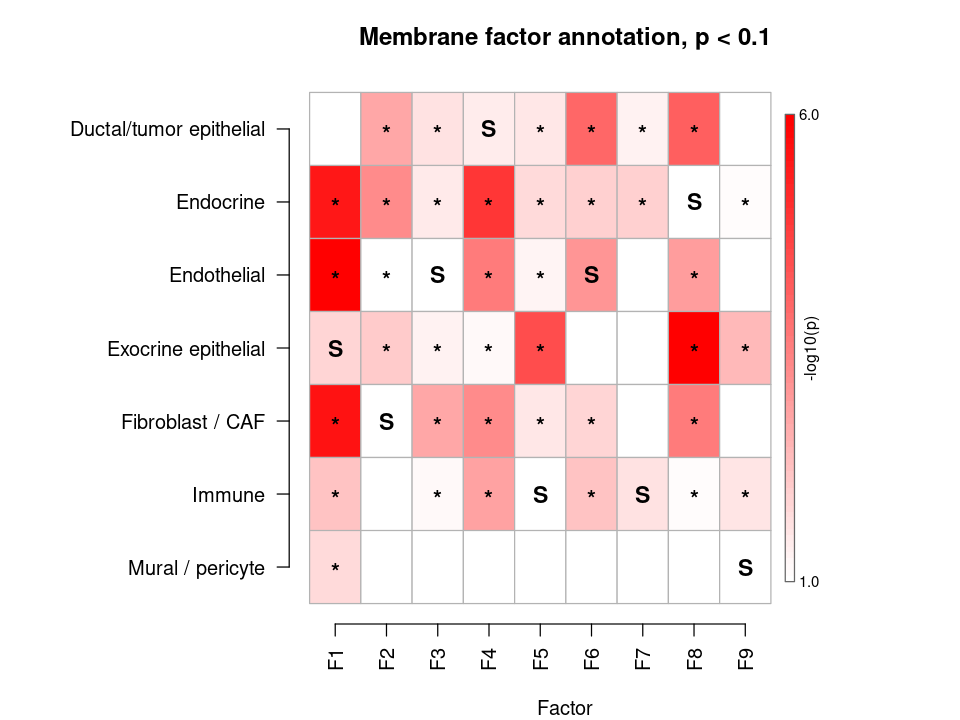

In [ ]:
p_thresh <- 0.1
membrane_score$plot_heatmap(p_thresh = p_thresh)

The pair plots show, for each factor, which target cell types have
significant evidence of admixture from each candidate source cell type.
The source evidence bar above each matrix summarizes which cell types
best explain the factor.

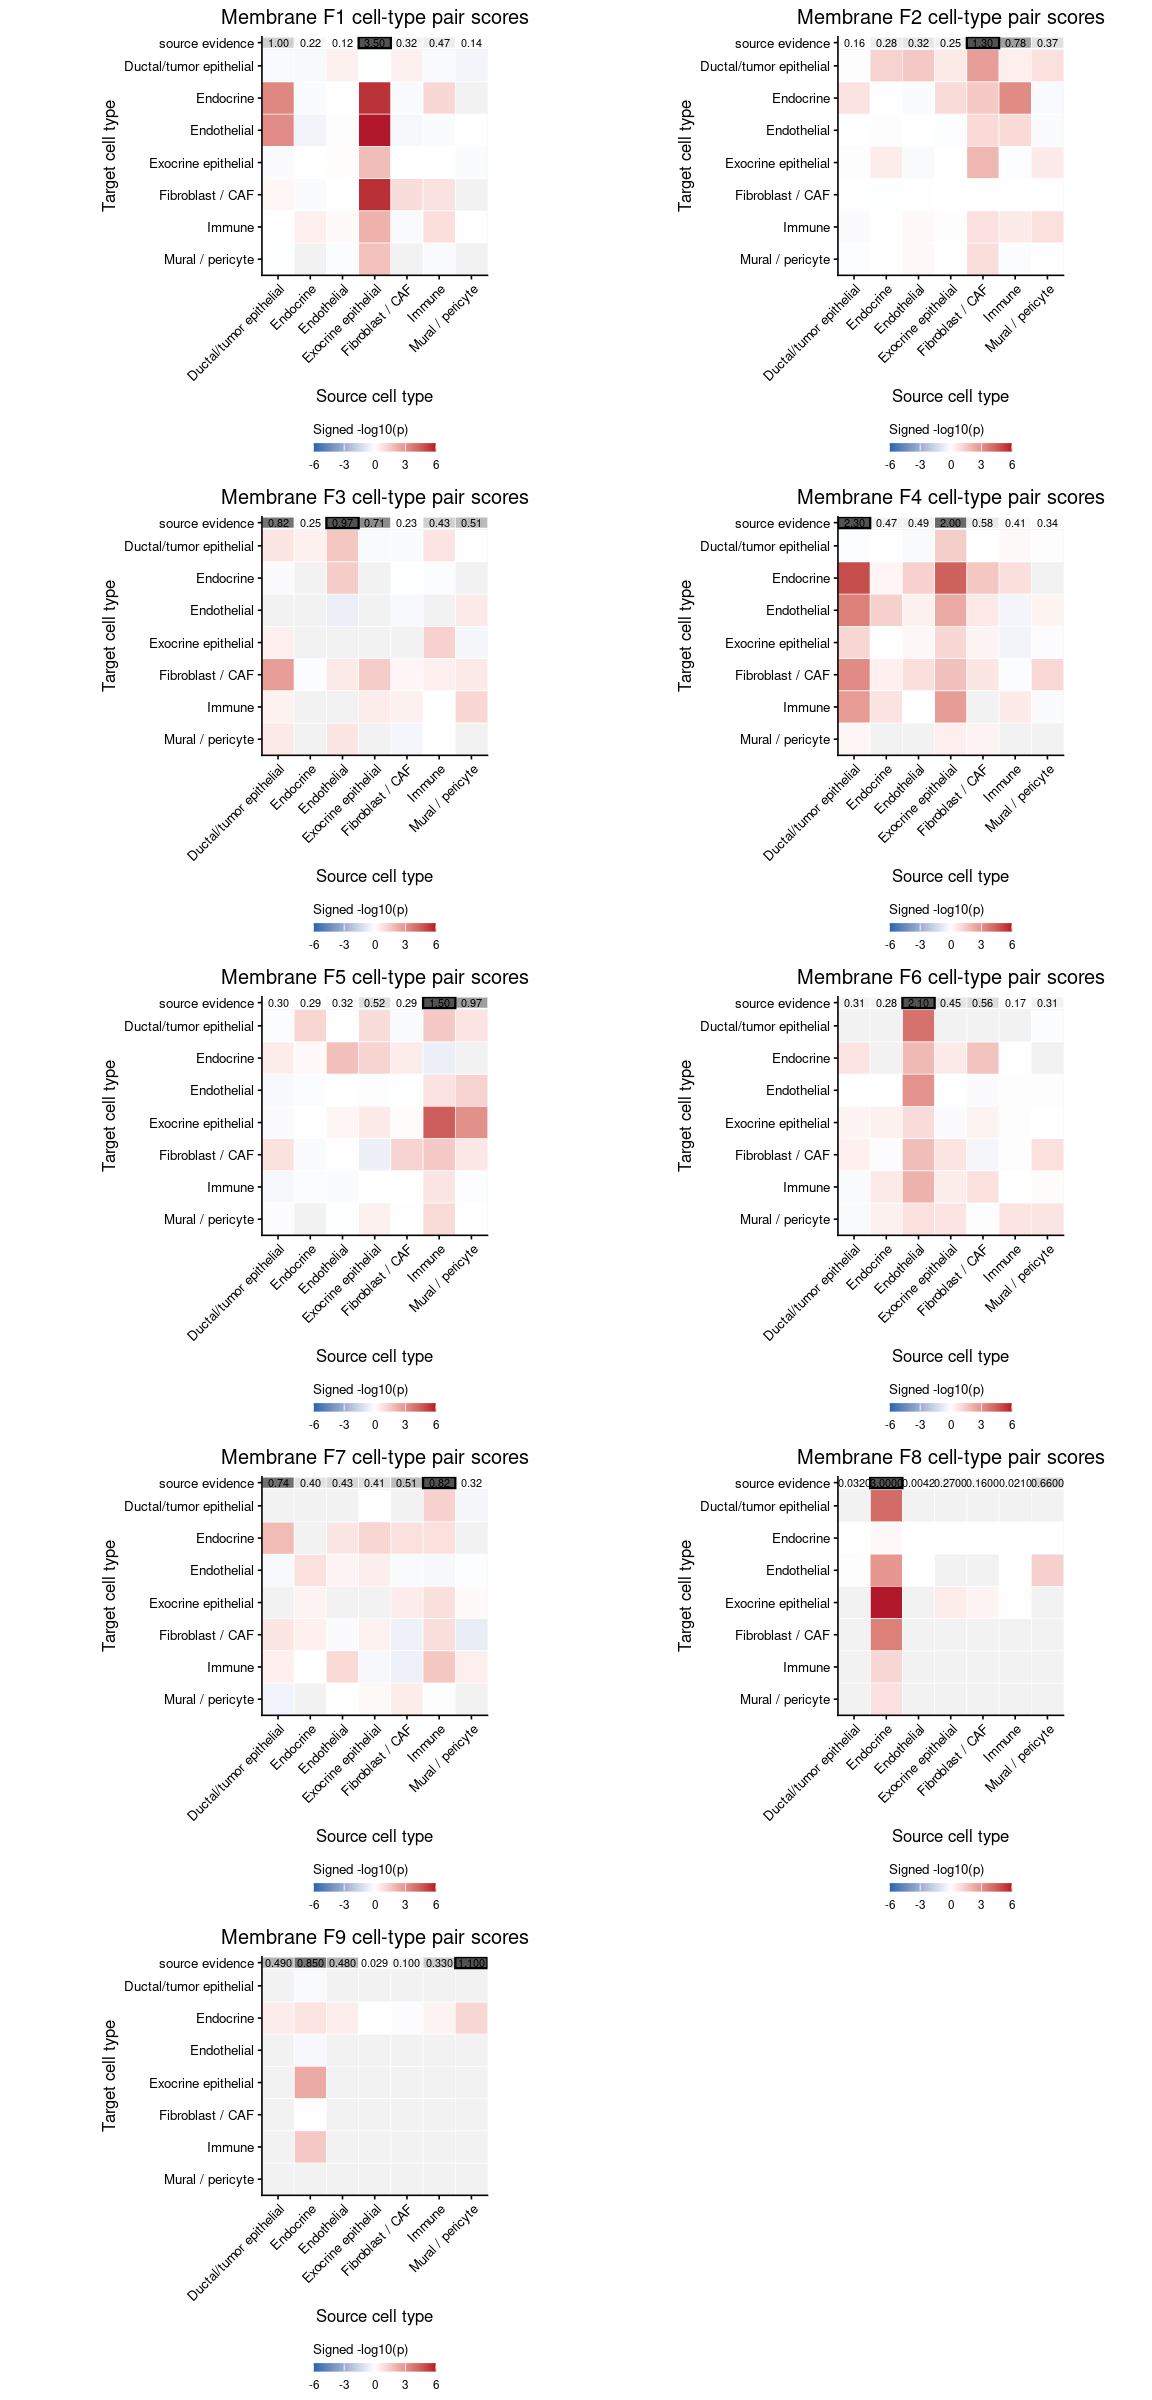

In [ ]:
membrane_score$plot_pairs()

Correction rules are the source-factor-target combinations that pass the
threshold and will be used to remove molecules from target cells.

In [ ]:
membrane_rules <- membrane_score$rules(p_thresh = p_thresh)
head(membrane_rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor    source_cell_type        target_cell_type      p_value
1      1 Exocrine epithelial               Endocrine 2.925136e-06
2      1 Exocrine epithelial             Endothelial 1.601047e-08
3      1 Exocrine epithelial        Fibroblast / CAF 2.406288e-06
4      1 Exocrine epithelial                  Immune 6.728052e-03
5      1 Exocrine epithelial        Mural / pericyte 1.987019e-02
6      2    Fibroblast / CAF Ductal/tumor epithelial 1.966083e-03

## Correct Counts

The correction step removes molecules assigned to significant admixture
factors in their target cell types. The result is persisted on disk and
can be collected as a sparse gene-by-cell matrix.

In [ ]:
membrane_correction <- membrane_score$correct(rules = membrane_rules,
  name = "membrane_clean")

membrane_correction$summary()

                cell_type n_cells n_modified_cells fraction_cells_modified
1                     all  125723            67921               0.5402432
2 Ductal/tumor epithelial   29986            19420               0.6476356
3               Endocrine    2212             1832               0.8282098
4             Endothelial    7026             6006               0.8548249
5     Exocrine epithelial   36329            24252               0.6675659
6        Fibroblast / CAF   28366             8975               0.3163999
7                  Immune   19251             7099               0.3687601
8        Mural / pericyte    2553              337               0.1320016
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1          6104194         5430829            673365                 0.11031186
2          1918375         1832584             85791                 0.04472066
3           125632          106320             19312                 0.15371880
4    

The molecule-removal plot is a basic diagnostic for how much correction
was applied across cell types. Large removals should be inspected
carefully.

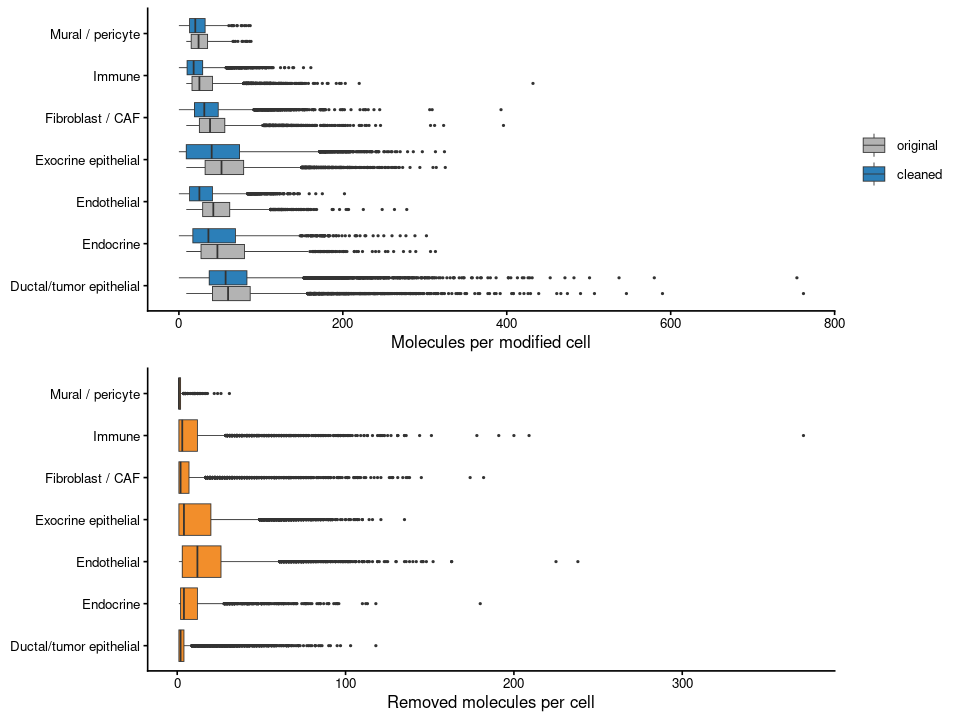

In [ ]:
membrane_correction$plot_removed_molecules()

## Add Results Back to Seurat

Finally, we attach cellAdmix outputs to the Seurat object. Factor
fractions and correction summaries are added to metadata. Corrected
counts are added as a new `cellAdmix` assay, leaving the original
`Xenium` assay unchanged.

In [ ]:
seu <- celladmix_add_to_seurat(seu, fit = fit, score = membrane_score,
  correction = membrane_correction, corrected_assay = "cellAdmix")

SeuratObject::Assays(seu)

[1] "Xenium"          "BlankCodeword"   "ControlCodeword" "ControlProbe"   
[5] "cellAdmix"      

 [1] "celladmix_dominant_factor"                  
 [2] "celladmix_factor_1_fraction"                
 [3] "celladmix_factor_2_fraction"                
 [4] "celladmix_factor_3_fraction"                
 [5] "celladmix_factor_4_fraction"                
 [6] "celladmix_factor_5_fraction"                
 [7] "celladmix_factor_6_fraction"                
 [8] "celladmix_factor_7_fraction"                
 [9] "celladmix_factor_8_fraction"                
[10] "celladmix_factor_9_fraction"                
[11] "celladmix_membrane_clean_n_removed"         
[12] "celladmix_membrane_clean_fraction_removed"  
[13] "celladmix_membrane_clean_n_molecules_before"
[14] "celladmix_membrane_clean_n_molecules_after" 

[1]    377 125723

At this point, downstream Seurat analyses can compare the original
`Xenium` assay with the corrected `cellAdmix` assay, or use the added
cellAdmix metadata for factor-aware visualization and diagnostics.